In [4]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load your CSV
df = pd.read_csv("multiclassKarawatha_Peri-Urban_vegetation_hollow_data_2009.csv")


# Drop columns not to be used in model as data creates noise
df = df.drop(columns=['siteID', 'latitude', 'longitude','plotId', 'endVisitDate'])

# Convert treeform to string so it doesn't use it as numerical data in the model
df['treeForm'] = df['treeForm'].astype(str)


# Separate features and target
X = df.drop(columns=['species'])      # Features
y = df['species']                     # Multiclass target

# Encode categorical variables
X = pd.get_dummies(X)                  # One-hot encode features
y = pd.factorize(y)[0]                 # Convert FuelType labels to numeric classes


# Save the new CSV
df.to_csv("updated_vegetation_hollow_data.csv", index=False)




Saving multiclassKarawatha_Peri-Urban_vegetation_hollow_data_2009.csv to multiclassKarawatha_Peri-Urban_vegetation_hollow_data_2009 (1).csv


Total samples in dataset: 124
Multiclass Classification (Species):
Kernel: rbf, Accuracy: 0.613


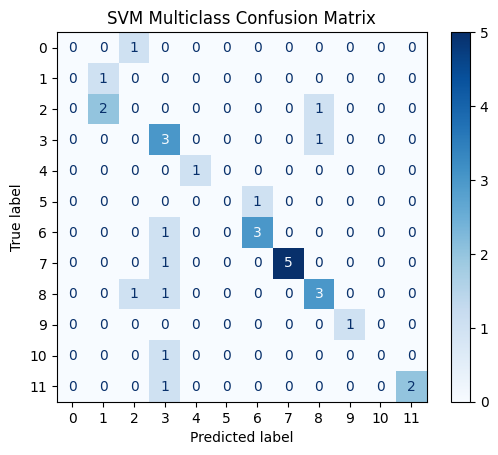

In [11]:
# SVM
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

print("Total samples in dataset:", len(X))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

#  Standardize features
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

#  Train and evaluate SVMs with different kernels
from sklearn.svm import SVC

print("Multiclass Classification (Species):")

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=1)
svm.fit(X_train_std, y_train)
y_pred = svm.predict(X_test_std)
acc = accuracy_score(y_test, y_pred)
print(f"Kernel: rbf, Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("SVM Multiclass Confusion Matrix")
plt.show()

Number of neighbors: 2, Accuracy: 0.516


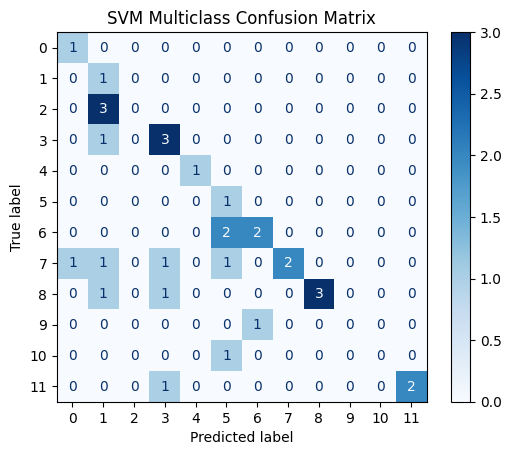

Number of neighbors: 3, Accuracy: 0.516


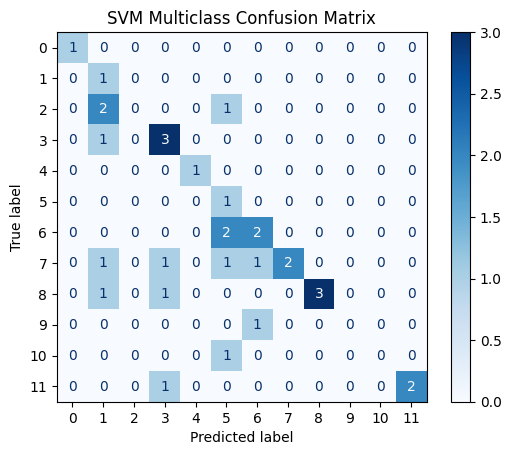

Number of neighbors: 4, Accuracy: 0.419


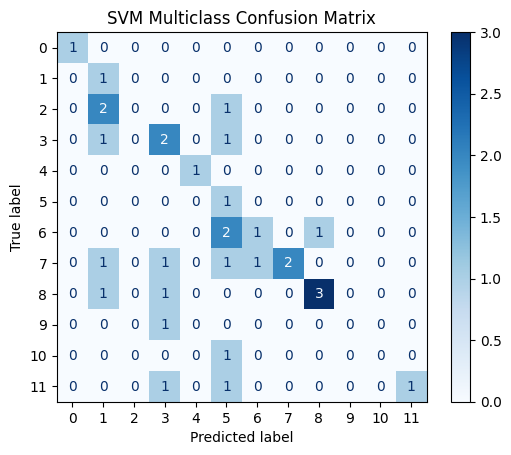

Number of neighbors: 6, Accuracy: 0.355


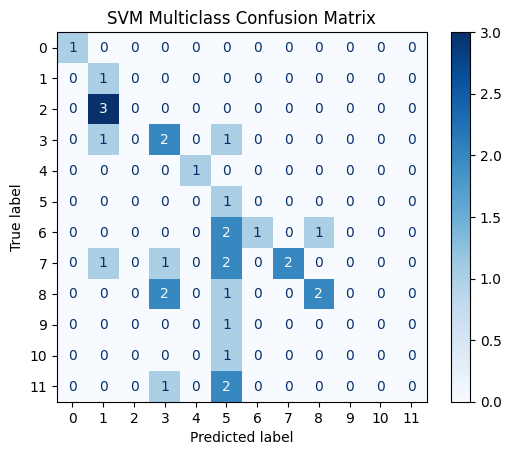

Number of neighbors: 8, Accuracy: 0.290


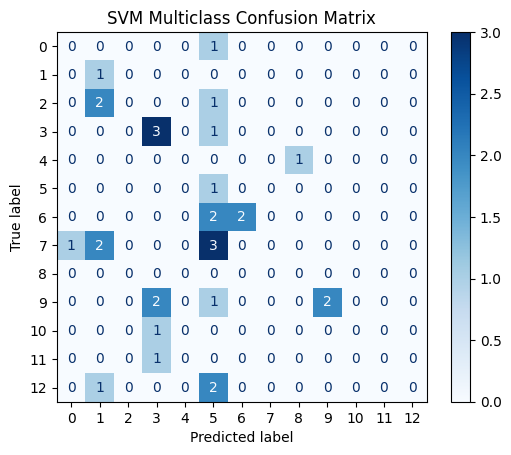

Number of neighbors: 10, Accuracy: 0.258


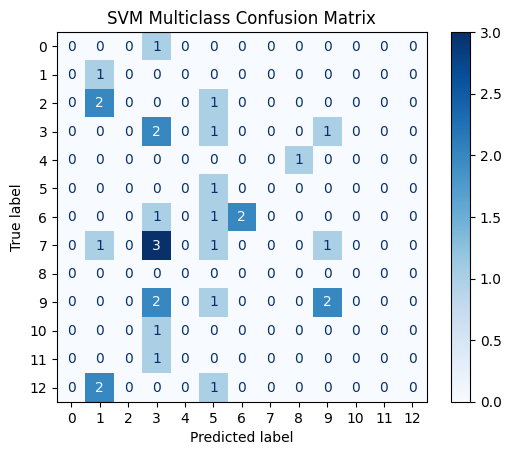

In [8]:
# K-NN Algorithm

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

#  Standardize features
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier

for n_neighbors in [2, 3, 4, 6, 8, 10]:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train_std, y_train)
    y_pred = knn.predict(X_test_std)
    acc = accuracy_score(y_test, y_pred)
    print(f"Number of neighbors: {n_neighbors}, Accuracy: {acc:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("SVM Multiclass Confusion Matrix")
    plt.show()



Max Depth: 3, Accuracy: 0.419


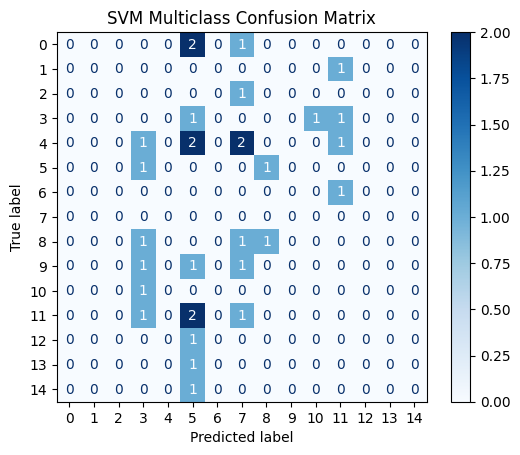

Max Depth: 4, Accuracy: 0.484


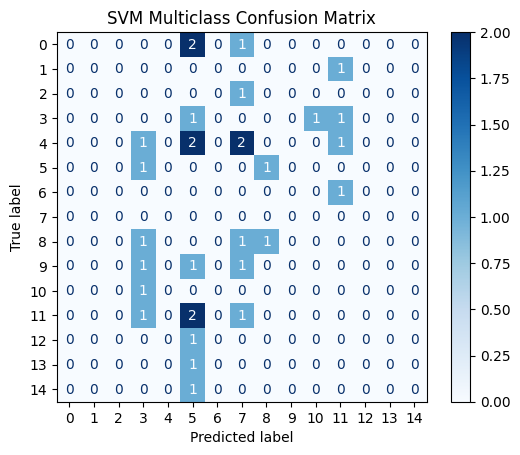

Max Depth: 5, Accuracy: 0.516


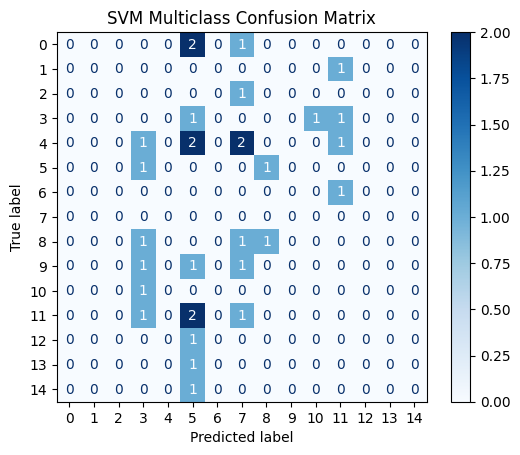

Max Depth: 6, Accuracy: 0.613


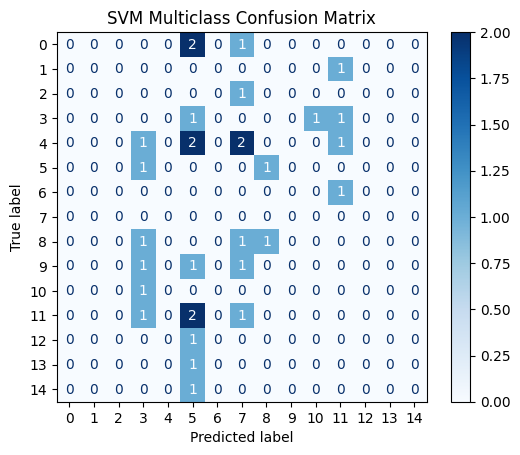

Max Depth: 7, Accuracy: 0.645


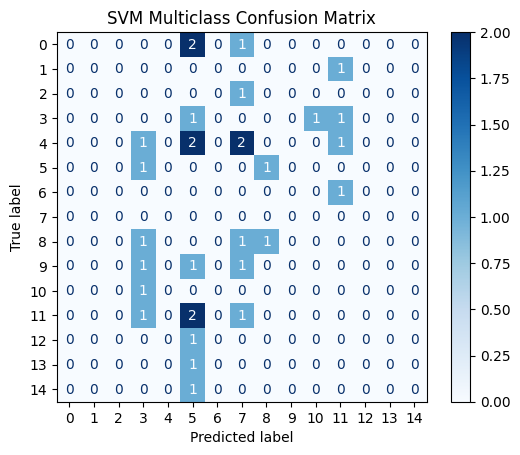

Max Depth: 8, Accuracy: 0.645


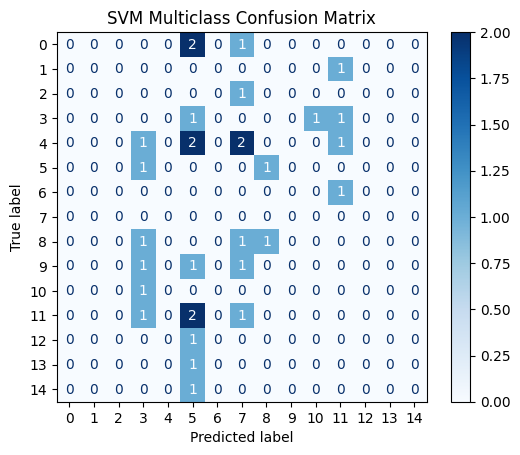

Max Depth: 9, Accuracy: 0.613


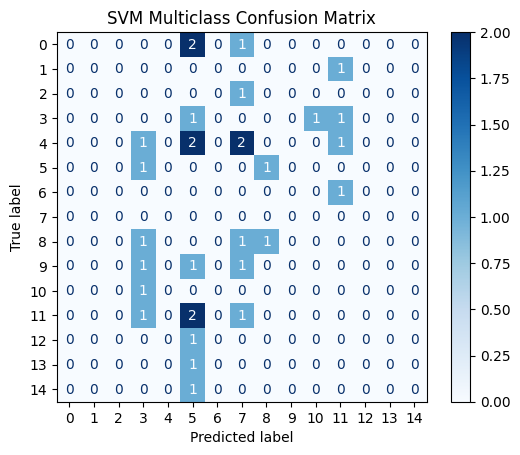

Max Depth: 10, Accuracy: 0.677


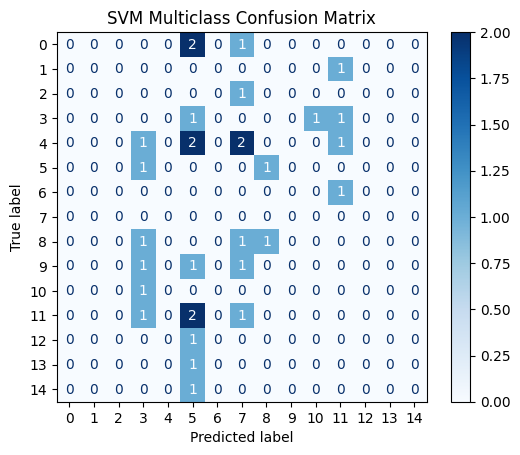

Max Depth: 11, Accuracy: 0.645


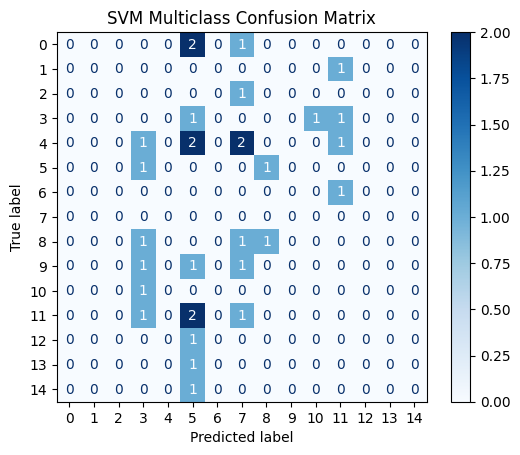

In [9]:
# Decision Tree

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)

for depth in range(3, 12):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=1)
    tree.fit(X_train, y_train)
    acc = accuracy_score(y_test, tree.predict(X_test))
    print(f"Max Depth: {depth}, Accuracy: {acc:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("SVM Multiclass Confusion Matrix")
    plt.show()




